# Figure demo

The cell below is tagged `#| label: figDemo`, which is what lets
`02-interactive-figures.md` embed its output with `:::{figure} #figDemo`.

This is Plotly's standard slider example. Replace it with your own work.

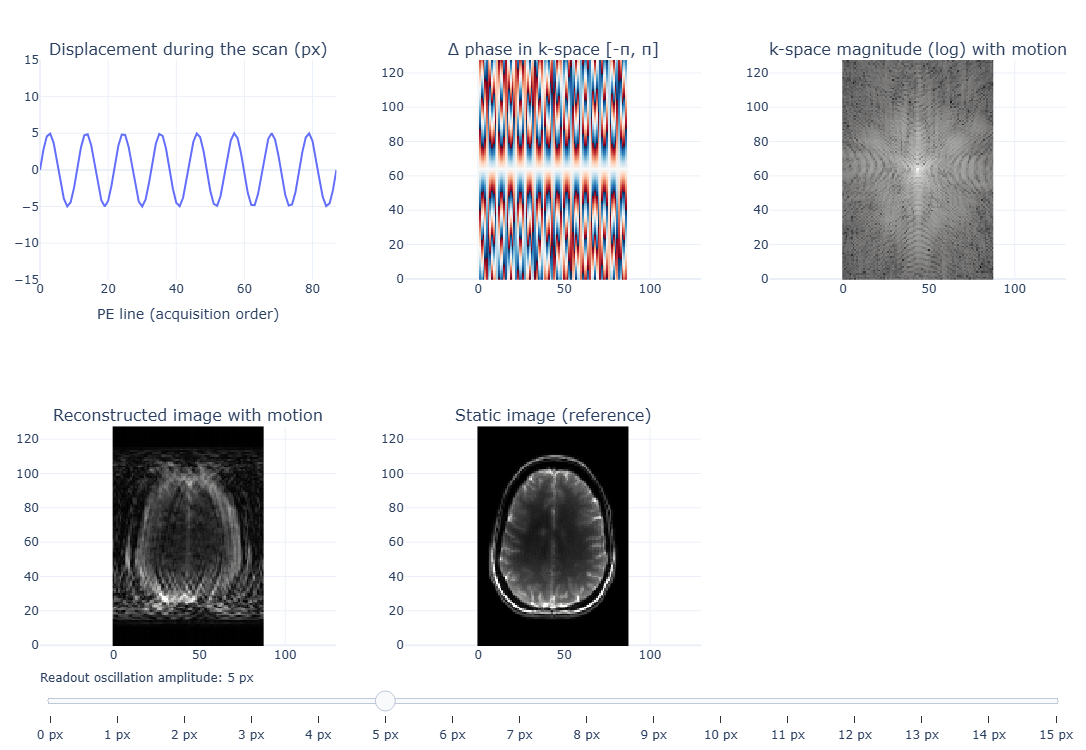

In [10]:
#| label: figMotionReadout
import numpy as np
import nibabel as nib
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = "plotly_mimetype+png"
PHASE = "./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-phase_MTS.nii.gz"
MAG = "./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-mag_MTS.nii.gz"

mag_data = nib.load(MAG).get_fdata()[:, :, 0]
phase_data = nib.load(PHASE).get_fdata()[:, :, 0]
complex_img = mag_data * np.exp(1j * phase_data)
to_k = lambda im: np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(im)))
to_img = lambda k: np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k)))
kspace = to_k(complex_img)
nx, ny = kspace.shape
mag_clean = np.abs(complex_img)
img_max = np.percentile(mag_clean, 99.5)

kx = np.fft.fftshift(np.fft.fftfreq(ny))[None, :]   # cycles/pixel, readout / frequency encode (axis 1)
t = np.linspace(0, 1, nx)[:, None]                  # when each PE line is acquired (0 -> 1)
N_CYCLES = 8                                        # motion periods during the whole scan


def readout_translation(amount):
    """Object oscillates along readout during the scan: line i is acquired
    with the object shifted by amount * sin(2*pi*N_CYCLES*t_i) px. By the Fourier shift
    theorem this is only a phase ramp -- the magnitude is untouched."""
    d = amount * np.sin(2 * np.pi * N_CYCLES * t)
    k_m = kspace * np.exp(-2j * np.pi * kx * d)
    return d[:, 0], k_m


def lighten(z):
    return np.round(z, 3).astype(np.float32)


amounts = np.arange(0, 16, 1)
frames_data = {}
for a in amounts:
    d, k_m = readout_translation(a)
    frames_data[a] = dict(
        disp=d,
        d_phase=lighten(np.angle(k_m * np.conj(kspace)).T),
        log_k=lighten(np.log(np.abs(k_m) + 1e-9).T),
        img=lighten(np.abs(to_img(k_m)).T),
    )

fig = make_subplots(rows=2, cols=3, subplot_titles=(
    "Displacement during the scan (px)", "Δ phase in k-space [-π, π]",
    "k-space magnitude (log) with motion",
    "Reconstructed image with motion", "Static image (reference)", ""))

default = 5
f0 = frames_data[default]
fig.add_trace(go.Scatter(x=np.arange(nx), y=f0["disp"], showlegend=False), row=1, col=1)      # trace 0
fig.add_trace(go.Heatmap(z=f0["d_phase"], zmin=-np.pi, zmax=np.pi, colorscale="RdBu",
                         showscale=False), row=1, col=2)                                      # trace 1
fig.add_trace(go.Heatmap(z=f0["log_k"], colorscale="gray", showscale=False), row=1, col=3)    # trace 2
fig.add_trace(go.Heatmap(z=f0["img"], zmin=0, zmax=img_max, colorscale="gray",
                         showscale=False), row=2, col=1)                                      # trace 3
fig.add_trace(go.Heatmap(z=mag_clean.T, zmin=0, zmax=img_max, colorscale="gray",
                         showscale=False), row=2, col=2)                                      # trace 4 (static)

# Each slider step jumps to a precomputed frame that updates traces 0-3
fig.frames = [go.Frame(name=str(a), traces=[0, 1, 2, 3], data=[
    go.Scatter(y=f["disp"]), go.Heatmap(z=f["d_phase"]),
    go.Heatmap(z=f["log_k"]), go.Heatmap(z=f["img"])])
    for a, f in frames_data.items()]

fig.update_xaxes(title_text="PE line (acquisition order)", row=1, col=1)
fig.update_yaxes(range=[-amounts.max(), amounts.max()], row=1, col=1)
for c, (r, col) in enumerate([(1, 2), (1, 3), (2, 1), (2, 2)], start=2):
    fig.update_yaxes(scaleanchor=f"x{c}", row=r, col=col)
fig.update_xaxes(visible=False, row=2, col=3)
fig.update_yaxes(visible=False, row=2, col=3)

fig.update_layout(
    width=1000, height=750, template="plotly_white",
    margin=dict(l=40, r=20, t=60, b=40),
    sliders=[dict(
        currentvalue=dict(prefix="Readout oscillation amplitude: "),
        active=int(default),
        steps=[dict(method="animate", label=f"{a} px",
                    args=[[str(a)], dict(mode="immediate", frame=dict(duration=0, redraw=True),
                                         transition=dict(duration=0))])
               for a in amounts],
    )],
)

fig

In [1]:
import numpy as np
import nibabel as nib
from scipy.ndimage import rotate
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import interact, IntSlider

PHASE = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-phase_MTS.nii.gz")
MAG = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-mag_MTS.nii.gz")

mag_data = (nib.load(MAG).get_fdata())[:, :, 0]
phase_data = (nib.load(PHASE).get_fdata())[:, :, 0]
complex_img = mag_data * np.exp(1j * phase_data)
to_k = lambda im: np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(im)))
to_img = lambda k: np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k)))
kspace = to_k(complex_img)
nx, ny = kspace.shape
mag_clean = np.abs(complex_img)

MOTION_START = 35      # fixed: first PE line acquired while moving
TOTAL_ROT = 15.0      # fixed: total rotation (deg) reached at the end of the motion

# Precompute rotated k-spaces on a 0.25 deg grid once, so moving the slider
# (and the error sweep) only copies rows instead of re-rotating every time.
ANGLE_STEP = 0.25
ANGLES = np.arange(0, TOTAL_ROT + ANGLE_STEP / 2, ANGLE_STEP)
K_ROT = [to_k(rotate(complex_img.real, a, reshape=False, order=1)
              + 1j * rotate(complex_img.imag, a, reshape=False, order=1)) for a in ANGLES]


def rotated_k(angle):
    return K_ROT[int(round(angle / ANGLE_STEP))]


def build_kspace(duration):
    """Object rotates linearly from 0 to TOTAL_ROT over `duration` PE lines
    starting at MOTION_START, then stays at TOTAL_ROT for the rest of the scan."""
    stop = MOTION_START + duration
    kspace_rot = kspace.copy()
    for i in range(MOTION_START, stop):
        kspace_rot[i, :] = rotated_k(TOTAL_ROT * (i - MOTION_START + 1) / duration)[i, :]
    kspace_rot[stop:, :] = rotated_k(TOTAL_ROT)[stop:, :]
    return kspace_rot


def rel_err(kspace_rot):
    return np.linalg.norm(np.abs(to_img(kspace_rot)) - mag_clean) / np.linalg.norm(mag_clean)


# error vs duration doesn't depend on the slider, so compute it once
durations = np.arange(1, nx - MOTION_START + 1, 2)
err = [rel_err(build_kspace(d)) for d in durations]


def update(duration=45):
    stop = MOTION_START + duration
    kspace_rot = build_kspace(duration)
    img_motion = to_img(kspace_rot)

    moving = np.full((nx, ny), np.nan)
    moving[MOTION_START:stop, :] = 1      # green: object rotating during these lines
    rotated = np.full((nx, ny), np.nan)
    rotated[stop:, :] = 1                  # red: object still, but at final angle

    fig = make_subplots(rows=3, cols=2,
                        specs=[[{}, {}], [{}, {}], [{"colspan": 2}, None]],
                        row_heights=[0.37, 0.37, 0.26],
                        subplot_titles=("k-space magnitude (log|.|)", "k-space phase",
                                        "Image magnitude", "Image phase",
                                        "Image error vs motion duration"))

    # row 1: k-space
    fig.add_trace(go.Heatmap(z=np.log(np.abs(kspace_rot) + 1e-9).T,
                              colorscale="gray", showscale=False), row=1, col=1)
    fig.add_trace(go.Heatmap(z=np.angle(kspace_rot).T, coloraxis="coloraxis"), row=1, col=2)
    for col in (1, 2):
        fig.add_trace(go.Heatmap(z=moving.T, colorscale=[[0, "green"], [1, "green"]],
                                  showscale=False, opacity=0.15, hoverinfo="skip"), row=1, col=col)
        fig.add_trace(go.Heatmap(z=rotated.T, colorscale=[[0, "red"], [1, "red"]],
                                  showscale=False, opacity=0.15, hoverinfo="skip"), row=1, col=col)

    # row 2: image
    fig.add_trace(go.Heatmap(z=np.abs(img_motion).T, colorscale="gray", showscale=False), row=2, col=1)
    fig.add_trace(go.Heatmap(z=np.angle(img_motion).T, coloraxis="coloraxis"), row=2, col=2)

    # row 3: error vs duration
    fig.add_trace(go.Scatter(x=durations, y=err, name="sweep"), row=3, col=1)
    fig.add_trace(go.Scatter(x=[duration], y=[rel_err(kspace_rot)], mode="markers",
                              marker=dict(color="green", size=10), name="current"), row=3, col=1)
    fig.add_vline(x=nx // 2 - MOTION_START + 1, line_dash="dash", line_width=1, row=3, col=1)  # motion reaches ky=0
    fig.update_xaxes(title_text="motion duration (lines)", range=[0, nx - MOTION_START], row=3, col=1)
    fig.update_yaxes(title_text="relative image error", range=[0, 1], row=3, col=1)
    for c, (r, col) in enumerate([(1, 1), (1, 2), (2, 1), (2, 2)], start=1):
        fig.update_yaxes(scaleanchor=f"x{c}" if c > 1 else "x", row=r, col=col)

    fig.update_layout(width=900, height=1150, template="plotly_white",
                       margin=dict(l=40, r=40, t=40, b=40),
                       legend=dict(x=0.85, y=0.2),
                       coloraxis=dict(colorscale="RdBu", cmin=-np.pi, cmax=np.pi,
                                      colorbar=dict(title="rad", len=0.7, y=0.65)))
    fig.show()


interact(
    update,
    duration=IntSlider(value=45, min=1, max=nx - MOTION_START, step=1, description="duration"),
)

interactive(children=(IntSlider(value=45, description='duration', max=53, min=1), Output()), _dom_classes=('wi…

<function __main__.update(duration=45)>

In [4]:
import numpy as np
import nibabel as nib
from scipy.ndimage import rotate
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import interact, IntSlider, FloatSlider

PHASE = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-phase_MTS.nii.gz")
MAG = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-mag_MTS.nii.gz")

mag_data = (nib.load(MAG).get_fdata())[:, :, 0]
phase_data = (nib.load(PHASE).get_fdata())[:, :, 0]
complex_img = mag_data * np.exp(1j * phase_data)
to_k = lambda im: np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(im)))
to_img = lambda k: np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k)))
kspace = to_k(complex_img)
nx, ny = kspace.shape
mag_clean = np.abs(complex_img)


def rotated_k(angle):
    return to_k(rotate(complex_img.real, angle, reshape=False, order=1)
                + 1j * rotate(complex_img.imag, angle, reshape=False, order=1))


def build_kspace(motion_start, motion_stop, total_rot):
    angle_rate = total_rot / max(motion_stop - motion_start - 1, 1)
    kspace_rot = kspace.copy()
    for i in range(motion_start, motion_stop):
        kspace_rot[i, :] = rotated_k((i - motion_start) * angle_rate)[i, :]
    kspace_rot[motion_stop:, :] = rotated_k((motion_stop - 1 - motion_start) * angle_rate)[motion_stop:, :]
    return kspace_rot


def rel_err(kspace_rot):
    return np.linalg.norm(np.abs(to_img(kspace_rot)) - mag_clean) / np.linalg.norm(mag_clean)


def update(motion_start=5, motion_stop=50, total_rot=1.0):
    motion_stop = max(motion_stop, motion_start + 1)
    L = motion_stop - motion_start

    kspace_rot = build_kspace(motion_start, motion_stop, total_rot)
    img_motion = to_img(kspace_rot)

    # sweep: same window length and total_rot, slide the start across k-space
    starts = np.arange(0, nx, 2)
    err = [rel_err(build_kspace(s, min(s + L, nx), total_rot)) for s in starts]

    moving = np.full((nx, ny), np.nan)
    moving[motion_start:motion_stop, :] = 1      # green: object rotating during these lines
    rotated = np.full((nx, ny), np.nan)
    rotated[motion_stop:, :] = 1                  # red: object still, but at final angle

    fig = make_subplots(rows=3, cols=2,
                        specs=[[{}, {}], [{}, {}], [{"colspan": 2}, None]],
                        row_heights=[0.37, 0.37, 0.26],
                        subplot_titles=("k-space magnitude (log|.|)", "k-space phase",
                                        "Image magnitude", "Image phase",
                                        "Image error vs motion window position"))

    # row 1: k-space
    fig.add_trace(go.Heatmap(z=np.log(np.abs(kspace_rot) + 1e-9).T,
                              colorscale="gray", showscale=False), row=1, col=1)
    fig.add_trace(go.Heatmap(z=np.angle(kspace_rot).T, coloraxis="coloraxis"), row=1, col=2)
    for col in (1, 2):
        fig.add_trace(go.Heatmap(z=moving.T, colorscale=[[0, "green"], [1, "green"]],
                                  showscale=False, opacity=0.15, hoverinfo="skip"), row=1, col=col)
        fig.add_trace(go.Heatmap(z=rotated.T, colorscale=[[0, "red"], [1, "red"]],
                                  showscale=False, opacity=0.15, hoverinfo="skip"), row=1, col=col)

    # row 2: image
    fig.add_trace(go.Heatmap(z=np.abs(img_motion).T, colorscale="gray", showscale=False), row=2, col=1)
    fig.add_trace(go.Heatmap(z=np.angle(img_motion).T, coloraxis="coloraxis"), row=2, col=2)

    # row 3: error vs window position
    fig.add_trace(go.Scatter(x=starts, y=err, name="sweep"), row=3, col=1)
    fig.add_trace(go.Scatter(x=[motion_start], y=[rel_err(kspace_rot)], mode="markers",
                              marker=dict(color="green", size=10), name="current"), row=3, col=1)
    fig.add_vline(x=nx // 2 - L // 2, line_dash="dash", line_width=1, row=3, col=1)  # window centred on ky=0
    fig.update_xaxes(title_text="motion window start (line)", range=[0, nx], row=3, col=1)    
    fig.update_yaxes(title_text="relative image error", range=[0, 1], row=3, col=1)
    for c, (r, col) in enumerate([(1, 1), (1, 2), (2, 1), (2, 2)], start=1):
        fig.update_yaxes(scaleanchor=f"x{c}" if c > 1 else "x", row=r, col=col)

    fig.update_layout(width=900, height=1150, template="plotly_white",
                       margin=dict(l=40, r=40, t=40, b=40),
                       legend=dict(x=0.85, y=0.2),
                       coloraxis=dict(colorscale="RdBu", cmin=-np.pi, cmax=np.pi,
                                      colorbar=dict(title="rad", len=0.7, y=0.65)))
    fig.show()


interact(
    update,
    motion_start=IntSlider(value=5, min=0, max=nx - 1, step=1, description="start"),
    motion_stop=IntSlider(value=50, min=1, max=nx, step=1, description="stop"),
    total_rot=FloatSlider(value=5.0, min=-180.0, max=180.0, step=5, description="deg"),
)

interactive(children=(IntSlider(value=5, description='start', max=87), IntSlider(value=50, description='stop',…

<function __main__.update(motion_start=5, motion_stop=50, total_rot=1.0)>

Actual sampled fraction: 0.117


/home/mathi/miniconda3/envs/devMyst/lib/python3.14/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 5 is too high: all coefficients will experience boundary effects.
  warnings.warn(


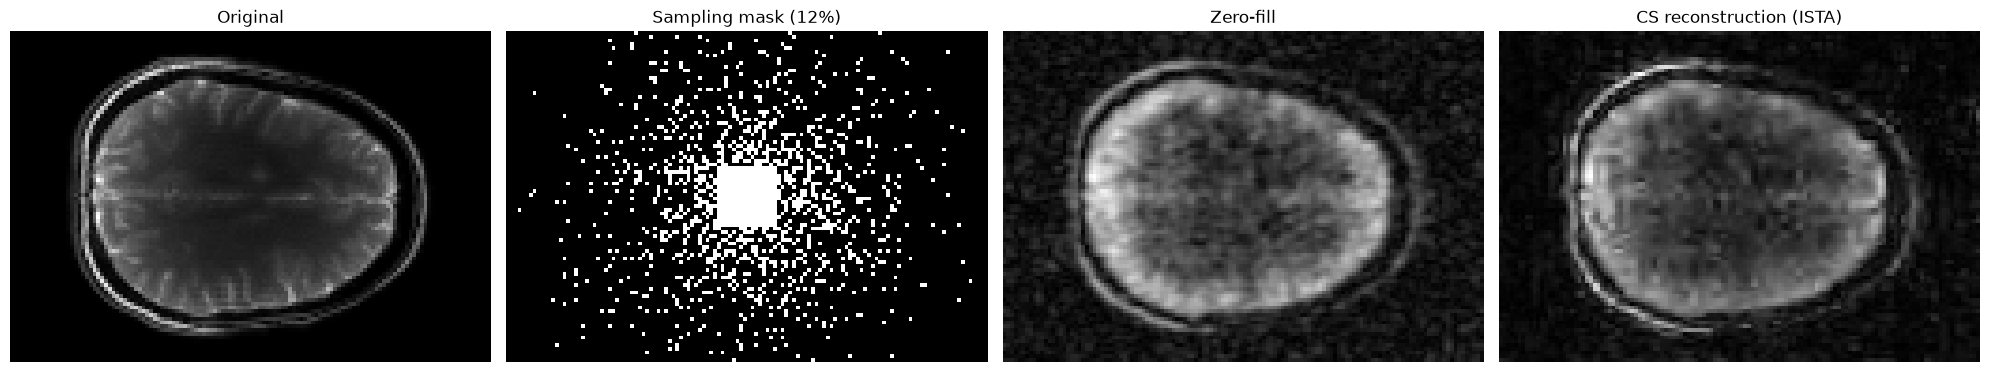

In [1]:
import numpy as np
import nibabel as nib
import pywt
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load data and build complex image / k-space
# ---------------------------------------------------------
PHASE = "./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-phase_MTS.nii.gz"
MAG   = "./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-mag_MTS.nii.gz"

mag_data   = nib.load(MAG).get_fdata()[:, :, 0]
phase_data = nib.load(PHASE).get_fdata()[:, :, 0]
complex_img = mag_data * np.exp(1j * phase_data)

to_k   = lambda im: np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(im)))
to_img = lambda k:  np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k)))

kspace    = to_k(complex_img)
mag_clean = np.abs(complex_img)

# ---------------------------------------------------------
# 2. Variable-density undersampling mask WITH calibration region
#    - fully sampled small square at center (preserves contrast)
#    - smoothly decaying random density everywhere else (low coherence)
# ---------------------------------------------------------
def variable_density_mask(shape, fraction, calib_size=16, power=3):
    ny, nx = shape
    cy, cx = ny // 2, nx // 2
    yy, xx = np.meshgrid(np.arange(ny) - cy, np.arange(nx) - cx, indexing='ij')
    r = np.sqrt(yy**2 + xx**2) / np.sqrt(cy**2 + cx**2)  # normalized radius 0..1

    prob = (1 - r) ** power
    prob = np.clip(prob, 0, 1)

    # scale so the *outer* region hits the target fraction on average
    prob = prob * fraction / prob.mean()
    prob = np.clip(prob, 0, 1)

    mask = np.random.rand(ny, nx) < prob

    # force full sampling in a small central calibration box
    half = calib_size // 2
    mask[cy-half:cy+half, cx-half:cx+half] = True

    return mask

np.random.seed(0)
sampling_fraction = 0.10   # try 0.20 first — 0.10 is genuinely aggressive per the paper
mask = variable_density_mask(kspace.shape, sampling_fraction, calib_size=16, power=3)

print(f"Actual sampled fraction: {mask.mean():.3f}")

# ---------------------------------------------------------
# 3. Normalize so wavelet thresholding is on a meaningful scale
# ---------------------------------------------------------
scale = np.abs(to_img(kspace)).max()
kspace_norm = kspace / scale

kspace_sampled_norm = kspace_norm * mask
zero_fill = to_img(kspace_sampled_norm) * scale

# ---------------------------------------------------------
# 4. Wavelet soft-thresholding (the sparsity-enforcing step)
# ---------------------------------------------------------
def wavelet_denoise(img, wavelet='db4', level=3, thresh=0.02):
    coeffs_r = pywt.wavedec2(img.real, wavelet, level=level)
    coeffs_i = pywt.wavedec2(img.imag, wavelet, level=level)

    def threshold_coeffs(coeffs):
        out = [coeffs[0]]  # leave approximation (cA) untouched
        for cH, cV, cD in coeffs[1:]:
            out.append((
                pywt.threshold(cH, thresh, mode='soft'),
                pywt.threshold(cV, thresh, mode='soft'),
                pywt.threshold(cD, thresh, mode='soft'),
            ))
        return out

    coeffs_r = threshold_coeffs(coeffs_r)
    coeffs_i = threshold_coeffs(coeffs_i)
    return pywt.waverec2(coeffs_r, wavelet) + 1j * pywt.waverec2(coeffs_i, wavelet)

# ---------------------------------------------------------
# 5. ISTA loop: alternate sparsity step <-> data-consistency step
#    (this is the "interference cancellation" the paper describes)
# ---------------------------------------------------------
n_iters = 100
thresh  = 0.02
wavelet = 'db4'
level   = 5

x = to_img(kspace_sampled_norm)      # start from zero-fill
y = kspace_sampled_norm              # measured (masked) k-space, normalized

for i in range(n_iters):
    x  = wavelet_denoise(x, wavelet=wavelet, level=level, thresh=thresh)  # sparsity
    kx = to_k(x)
    kx[mask] = y[mask]                                                    # data consistency
    x  = to_img(kx)

recon_cs = np.abs(x) * scale

# ---------------------------------------------------------
# 6. Compare
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(mag_clean, cmap='gray');               axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray');                    axes[1].set_title(f'Sampling mask ({mask.mean()*100:.0f}%)'); axes[1].axis('off')
axes[2].imshow(np.abs(zero_fill), cmap='gray');       axes[2].set_title('Zero-fill'); axes[2].axis('off')
axes[3].imshow(recon_cs, cmap='gray');                axes[3].set_title('CS reconstruction (ISTA)'); axes[3].axis('off')
plt.tight_layout()
plt.show()